In [2]:
from matplotlib import pyplot as plt
import numpy as np
from PIL import Image
from skimage.color import rgb2lab
from sklearn.cluster import KMeans
from scipy.ndimage import median_filter
import cv2

path = "imgs/frame.jpeg"

In [8]:
class WordfeudMap:

    FINE_H = [0.90, 0.95, 1.0, 1.05, 1.10, 1.15]
    FINE_W = [0.90, 0.95, 1.0, 1.05, 1.10, 1.15]

    def __init__(self, img_path):
        self.img = self.load_img(img_path)
        self.board_offset = 10
        self.tile_size = self.img.shape[1] // 15
        self.x = np.arange(15) * self.tile_size
        self.y = np.arange(15) * self.tile_size

        self.colormap = {
            (41,  44,  49 ): 0,
            (234, 233, 222): 1,
            (117, 141, 95 ): 2,
            (53,  97,  138): 3,
            (184, 121, 51 ): 4,
            (130, 52,  49 ): 5,
        }
        self._color_keys = np.array(list(self.colormap.keys()), dtype=np.float32)
        self._color_vals = np.array(list(self.colormap.values()), dtype=np.int32)

        self.letter_data = {
            "A": {"antal": 7, "point": 1}, "B": {"antal": 4, "point": 3},
            "C": {"antal": 2, "point": 8}, "D": {"antal": 5, "point": 2},
            "E": {"antal": 9, "point": 1}, "F": {"antal": 3, "point": 3},
            "G": {"antal": 3, "point": 3}, "H": {"antal": 2, "point": 4},
            "I": {"antal": 4, "point": 3}, "J": {"antal": 2, "point": 4},
            "K": {"antal": 4, "point": 3}, "L": {"antal": 5, "point": 2},
            "M": {"antal": 3, "point": 4}, "N": {"antal": 7, "point": 1},
            "O": {"antal": 5, "point": 2}, "P": {"antal": 2, "point": 4},
            "R": {"antal": 7, "point": 1}, "S": {"antal": 6, "point": 2},
            "T": {"antal": 6, "point": 2}, "U": {"antal": 3, "point": 3},
            "V": {"antal": 3, "point": 4}, "X": {"antal": 1, "point": 8},
            "Y": {"antal": 2, "point": 4}, "Z": {"antal": 1, "point": 9},
            "Æ": {"antal": 2, "point": 4}, "Ø": {"antal": 2, "point": 4},
            "Å": {"antal": 2, "point": 4},
        }

        # Cache binarised + cropped templates
        img_dir = "letters/"
        self._template_cache = {}
        for letter in self.letter_data:
            try:
                raw = np.array(Image.open(f"{img_dir}{letter.lower()}.png"))
                bw = self._to_binary(raw)
                self._template_cache[letter] = self._crop_foreground(bw)
            except FileNotFoundError:
                pass

    # ── static helpers ────────────────────────────────────────────────────

    @staticmethod
    def _to_binary(img):
        if img.ndim == 3 and img.shape[2] == 4:
            img = img[:, :, :3]
        gray = rgb2lab(img)[:, :, 0]
        return (gray < 20).astype(np.uint8)

    @staticmethod
    def _crop_foreground(mask):
        coords = np.argwhere(mask > 0)
        if coords.size == 0:
            return mask
        y0, x0 = coords.min(axis=0)
        y1, x1 = coords.max(axis=0) + 1
        return mask[y0:y1, x0:x1]

    @staticmethod
    def _strip_border(img, frac=0.08):
        """Crop outer border to remove dark board gaps."""
        H, W = img.shape[:2]
        dy, dx = int(H * frac), int(W * frac)
        return img[dy:H - dy, dx:W - dx]

    @staticmethod
    def _dice(a, b):
        inter = float(np.sum(a & b))
        denom = float(a.sum() + b.sum())
        return (2.0 * inter / denom) if denom else 0.0

    @staticmethod
    def _chamfer_score(a, b, tolerance=5.0):
        """Chamfer-distance-based similarity (higher = better).

        Unlike Dice, this gives partial credit for strokes that are
        *close* but not exactly overlapping — tolerating stroke-width
        and proportion differences.

        tolerance controls how many pixels of distance are forgiven.
        With tolerance=5, a mean distance of 2px scores ~0.82.
        """
        a_mask = a > 0
        b_mask = b > 0
        if not a_mask.any() or not b_mask.any():
            return 0.0
        dist_a = cv2.distanceTransform((~a_mask).astype(np.uint8), cv2.DIST_L2, 3)
        dist_b = cv2.distanceTransform((~b_mask).astype(np.uint8), cv2.DIST_L2, 3)
        d_ab = float(dist_b[a_mask].mean())
        d_ba = float(dist_a[b_mask].mean())
        return float(np.exp(-(d_ab + d_ba) / (2.0 * tolerance)))

    # ── image loading ─────────────────────────────────────────────────────

    def load_img(self, img_path):
        img = np.array(Image.open(img_path))[558:-250]
        kmeans = KMeans(n_clusters=8, random_state=0).fit(img.reshape(-1, 3))
        quantized = kmeans.cluster_centers_[kmeans.labels_].astype(np.uint8)
        return quantized.reshape(img.shape)

    # ── board colour map ──────────────────────────────────────────────────

    def closest_color(self, rgb):
        dists = np.linalg.norm(self._color_keys - np.array(rgb, dtype=np.float32), axis=1)
        return int(self._color_vals[np.argmin(dists)])

    def img_to_map(self):
        X, Y = np.meshgrid(self.x, self.y)
        X += self.board_offset
        points = np.column_stack([Y.ravel(), X.ravel()])
        rows, cols = zip(*points)
        samples = self.img[rows, cols, :].reshape(225, 3).astype(np.float32)
        dists = np.linalg.norm(
            samples[:, None, :] - self._color_keys[None, :, :], axis=2
        )
        labels = self._color_vals[np.argmin(dists, axis=1)]
        return labels.reshape(15, 15)

    # ── tile extraction ───────────────────────────────────────────────────

    def tile_from_coord(self, xi, yi):
        return self.img[
            self.x[xi] : self.x[xi] + self.tile_size - self.board_offset,
            self.y[yi] : self.y[yi] + self.tile_size,
        ]

    def available_letter_imgs(self):
        bottom_img = self.img[-155:-20, 20:-20]
        letter_W = 130
        tile_W = bottom_img.shape[1] // 7
        return [bottom_img[:, i * tile_W : i * tile_W + letter_W] for i in range(7)]

    # ── core: template matching ───────────────────────────────────────────

    @staticmethod
    def _match_score(tmpl_bw, target_bw):
        """Multi-scale template matching with chamfer scoring.

        1. Compute base scale (height-matched).
        2. Try FINE_H × FINE_W anisotropic adjustments.
        3. For each, use cv2.matchTemplate for fast position search.
        4. Score the best position with chamfer distance.
        """
        tH, tW = target_bw.shape
        th, tw = tmpl_bw.shape
        base_scale = tH / th

        tgt_f32 = target_bw.astype(np.float32)
        tgt_sum = float(target_bw.sum())

        best_score = -1.0
        best_fitted = None

        for fh in WordfeudMap.FINE_H:
            for fw in WordfeudMap.FINE_W:
                new_h = max(1, round(th * base_scale * fh))
                new_w = max(1, round(tw * base_scale * fw))

                if new_h > tH and new_w > tW:
                    continue

                # Smooth resize + re-threshold
                resized = cv2.resize(
                    tmpl_bw.astype(np.float32), (new_w, new_h),
                    interpolation=cv2.INTER_LINEAR,
                )
                resized = (resized >= 0.5).astype(np.float32)

                tmpl_sum = float(resized.sum())
                if tmpl_sum == 0:
                    continue

                # Pad search image if template exceeds target in one dimension
                pad_h = max(0, new_h - tH)
                pad_w = max(0, new_w - tW)
                if pad_h > 0 or pad_w > 0:
                    search_img = np.zeros((tH + pad_h, tW + pad_w), dtype=np.float32)
                    search_img[:tH, :tW] = tgt_f32
                else:
                    search_img = tgt_f32

                # Fast position search via cross-correlation
                match_map = cv2.matchTemplate(search_img, resized, cv2.TM_CCORR)
                _, max_inter, _, max_loc = cv2.minMaxLoc(match_map)
                best_x, best_y = max_loc

                # Quick Dice pre-filter: skip if clearly worse
                denom = tmpl_sum + tgt_sum
                fast_dice = 2.0 * max_inter / denom if denom else 0.0
                if fast_dice < best_score * 0.5:
                    continue

                # Place template at best position
                fitted = np.zeros((tH, tW), dtype=np.uint8)
                src_y0 = max(0, -best_y)
                src_x0 = max(0, -best_x)
                dst_y0 = max(0, best_y)
                dst_x0 = max(0, best_x)
                copy_h = min(new_h - src_y0, tH - dst_y0)
                copy_w = min(new_w - src_x0, tW - dst_x0)
                if copy_h > 0 and copy_w > 0:
                    fitted[dst_y0:dst_y0 + copy_h, dst_x0:dst_x0 + copy_w] = (
                        resized[src_y0:src_y0 + copy_h, src_x0:src_x0 + copy_w]
                        .astype(np.uint8)
                    )

                # Chamfer scoring (tolerant of stroke-width differences)
                score = WordfeudMap._chamfer_score(fitted, target_bw)
                if score > best_score:
                    best_score = score
                    best_fitted = fitted

        if best_fitted is None:
            best_fitted = np.zeros((tH, tW), dtype=np.uint8)

        return best_score, best_fitted

    # ── public API ────────────────────────────────────────────────────────

    def tile_to_text(self, tile):
        if not self._template_cache:
            print("No templates loaded")
            return None

        tile_bw = self._crop_foreground(self._to_binary(self._strip_border(tile)))

        best_match = None
        best_score = -1.0

        for letter, tmpl_bw in self._template_cache.items():
            score, _ = self._match_score(tmpl_bw, tile_bw)
            if score > best_score:
                best_score = score
                best_match = letter

        if best_match is not None:
            print(f"Best match: {best_match}  score={best_score:.4f}")
        else:
            print("No match found")

        return best_match


WF = WordfeudMap(path)
mapped = WF.img_to_map()
tile = WF.tile_from_coord(6, 6)
WF.tile_to_text(tile)

letter_imgs = WF.available_letter_imgs()
WF.tile_to_text(letter_imgs[6])

Best match: K  score=0.9576
Best match: N  score=0.9904


'N'

In [52]:
def compare_letter(img, letters=("A", "Å")):
    tile_bw = WordfeudMap._crop_foreground(WordfeudMap._to_binary(WordfeudMap._strip_border(img)))
    img_dir = "letters/"
    for letter in letters:
        raw = np.array(Image.open(f"{img_dir}{letter.lower()}.png"))
        tmpl_bw = WordfeudMap._crop_foreground(WordfeudMap._to_binary(raw))
        score, fitted = WordfeudMap._match_score(tmpl_bw, tile_bw)
        dice = WordfeudMap._dice(fitted, tile_bw)
        print(f"{letter}: chamfer={score:.4f}  dice={dice:.4f}")

compare_letter(letter_imgs[2])

A: chamfer=0.8595  dice=0.7951
Å: chamfer=0.8912  dice=0.7347


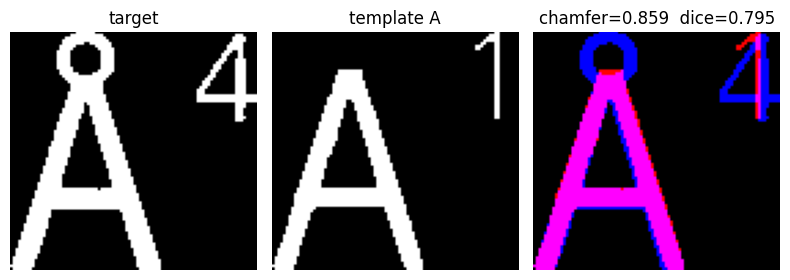

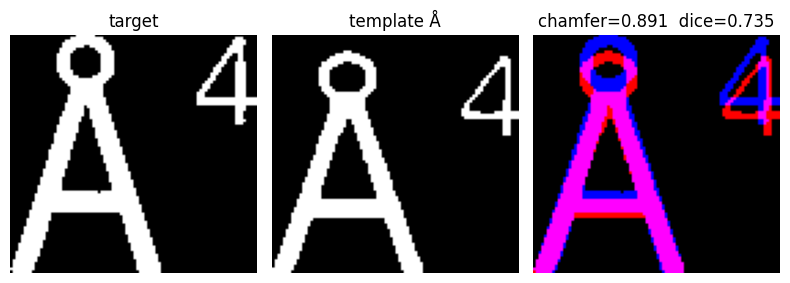

In [53]:
def overlay_letter(img, letters=("A", "Å")):
    target_bw = WordfeudMap._crop_foreground(WordfeudMap._to_binary(WordfeudMap._strip_border(img)))
    H, W = target_bw.shape
    img_dir = "letters/"
    for letter in letters:
        raw = np.array(Image.open(f"{img_dir}{letter.lower()}.png"))
        tmpl_bw = WordfeudMap._crop_foreground(WordfeudMap._to_binary(raw))
        score, fitted = WordfeudMap._match_score(tmpl_bw, target_bw)
        dice = WordfeudMap._dice(fitted, target_bw)

        overlay = np.zeros((H, W, 3), dtype=np.float32)
        overlay[..., 0] = fitted
        overlay[..., 2] = target_bw

        fig, axes = plt.subplots(1, 3, figsize=(8, 3))
        axes[0].imshow(target_bw, cmap="gray")
        axes[0].set_title("target")
        axes[1].imshow(fitted, cmap="gray")
        axes[1].set_title(f"template {letter}")
        axes[2].imshow(overlay)
        axes[2].set_title(f"chamfer={score:.3f}  dice={dice:.3f}")
        for ax in axes:
            ax.axis("off")
        plt.tight_layout()
        plt.show()

overlay_letter(letter_imgs[2])